# <u>Main objective</u>
I set out to distinguish whether the top 25 CNN algortihms submitted to paper 'Validation of artificial intelligence prediction models for skin cancer diagnosis using dermoscopy images the 2019 International Skin Imaging Collaboration Grand Challenge' are effective and the use of CNN on these image is fair.

Set out to do this by first evaluating dataset that has dermoscopic images has a clear abundance in each 'catergory' to decide wheter we can reach a conclusion of CNN effectiveness

Then evaluated paper of top 25 algorithms using the dataet to determine its effectiveness on the images presented.


In our context we are using Convolutional Neural Networks (CNNs) in cancer classification where we identfy types of cancers by the network identifying and adapting to patterns and features in medical images. Depending on how the image was collected (e.g., X-rays, MRIs, CT scans, histopathological slides) classifcation can vary.

In [106]:
# Read data from excel.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools
from scipy.stats import norm
pd.__version__
raw = pd.read_csv('Book1.csv')

# <u>Describing Dataset</u>
HAM1000 is a zip file containing over 1000 images of skin with there website quoting 'dermatoscopic images from different populations, acquired and stored by different modalities. The final dataset consists of 10015 dermatoscopic images which can serve as a training set for academic machine learning purposes.' 

In [107]:
# show variables
raw.head(0)

,lesion_id,image_id,dx,dx_type,age,sex,localization


Displayed above are the different charecteristics each image has

# KEY

 dx - Actinic keratoses and intraepithelial carcinoma / Bowen's disease (akiec), basal cell carcinoma (bcc), benign keratosis-like lesions (solar lentigines / seborrheic keratoses and lichen-planus like keratoses, bkl), dermatofibroma (df), melanoma (mel), melanocytic nevi (nv) and vascular lesions (angiomas, angiokeratomas, pyogenic granulomas and hemorrhage, vasc).


 dx type - histopathology (histo), the ground truth for the rest of the cases is either follow-up examination (follow_up), expert consensus (consensus), or confirmation by in-vivo confocal microscopy (confocal).






In [108]:
(pd.crosstab(index=raw['dx'], columns=raw['localization'])
 .style
 .background_gradient(cmap='viridis', axis=None)
 )

localization,abdomen,acral,back,chest,ear,face,foot,genital,hand,lower extremity,neck,scalp,trunk,unknown,upper extremity
dx,,,,,,,,,,,,,,,
akiec,5,0,29,12,3,113,0,0,13,65,10,14,1,0,62
bcc,18,0,186,47,0,101,4,0,2,58,14,19,11,5,49
bkl,42,0,202,74,6,319,1,2,14,174,31,34,73,23,104
df,4,0,2,0,0,0,2,1,0,82,0,0,0,0,24
mel,66,0,324,68,17,104,28,0,1,192,29,14,47,10,213
nv,860,7,1427,200,30,100,284,45,55,1479,81,45,1241,196,655
vasc,27,0,22,6,0,8,0,0,5,27,3,2,31,0,11


Purple = least value
Yellow = max value

In [109]:
cross_table = pd.crosstab(index=raw['dx'], columns=raw['localization'], margins=True, margins_name='Total')

# Display the crosstab with styling
styled_cross_table = (cross_table
                      .style
                      .background_gradient(cmap='viridis', axis=None)
                     )

styled_cross_table

localization,abdomen,acral,back,chest,ear,face,foot,genital,hand,lower extremity,neck,scalp,trunk,unknown,upper extremity,Total
dx,,,,,,,,,,,,,,,,
akiec,5,0,29,12,3,113,0,0,13,65,10,14,1,0,62,327
bcc,18,0,186,47,0,101,4,0,2,58,14,19,11,5,49,514
bkl,42,0,202,74,6,319,1,2,14,174,31,34,73,23,104,1099
df,4,0,2,0,0,0,2,1,0,82,0,0,0,0,24,115
mel,66,0,324,68,17,104,28,0,1,192,29,14,47,10,213,1113
nv,860,7,1427,200,30,100,284,45,55,1479,81,45,1241,196,655,6705
vasc,27,0,22,6,0,8,0,0,5,27,3,2,31,0,11,142
Total,1022,7,2192,407,56,745,319,48,90,2077,168,128,1404,234,1118,10015


The colormap shows the abundance of nv images comapared others with 6705/10015 images belonging to the cancer type. BKL and mel are also worth investigating with 11 perecnt of images being assigned to the type. Table also shows that investigating all other types does not create an accurate conclusion on the effectiveness on CNN with the 4th highest amount being BCC which accounts for 5 perecnt. Comparing data output with one of paramaters of over 50 perecent whilst others are less than 5 percent means correlation that may be discovered is void.

However still worth investigating Nevi.

Now load in paper to try and find any relation between CNN and dataset


First 2 letters represent type of cancer being displayed
Last 2 letters represent type of cancer CNN has assosciated it with
Duplicate in headings ie. NV-NV a true positive - Algorithm has correctly assigned the type of cancer to image
NT stands for not trained

In [110]:
cf = pd.read_csv('nevi confusion matrix.csv')
(cf.head(65)
 .style
 .background_gradient(cmap='plasma', axis=None)
 )

,Unnamed: 0,NV-NV,NV-BKL,NV-MEL,NV-SCC,NV-AK,NV-BCC,NV-VASC,NV-DF,NV-NT
0,Ref,0.810000,0.033000,0.080000,0.003900,0.010000,0.033000,0.0015,0.007700,0.018000
1,No crust,0.820000,0.030000,0.080000,0.003000,0.010000,0.032000,0.0015,0.007600,0.017000
2,Crust,0.350000,0.240000,0.110000,0.061000,0.039000,0.110000,0,0.018000,0.081000
3,No hair,0.820000,0.027000,0.080000,0.003300,0.010000,0.031000,0.0015,0.008100,0.017000
4,Hair,0.780000,0.052000,0.079000,0.005400,0.010000,0.039000,0.0014,0.006700,0.023000
5,No pen,0.820000,0.031000,0.076000,0.004000,0.011000,0.030000,0.0015,0.007300,0.016000
6,Pen,0.760000,0.043000,0.098000,0.003000,0.009500,0.047000,0.0011,0.009900,0.030000
7,No pigmentation,0.350000,0.089000,0.031000,0.065000,0.063000,0.240000,0.012,0.044000,0.099000
8,Pigmentation,0.830000,0.032000,0.082000,0.001900,0.008800,0.026000,0..0011,0.006600,0.016000
9,No ulceration,0.810000,0.033000,0.080000,0.003900,0.010000,0.033000,0.0015,0.007800,0.018000


Heat map shows CNN is highly effective with mostly yellow on NV-NV indicating true positive results. 

In [111]:
pf = pd.read_csv('Anatomical Site confusion matrix.csv')
(pf.head(65)
 .style
 .background_gradient(cmap='plasma', axis=None)
 )

,Anatomical site,NV-NV,NV-BKL,NV-MEL,NV-SCC,NV-AK,NV-BCC,NV-VASC,NV-DF,NV-NT,BKL-NV,BKL-BKL,BKL-MEL,BKL-SCC,BKL-AK,BKL-BCC,BKL-VASC,BKL-DF,BKL-NT,MEL-NV,MEL-BKL,MEL-MEL,MEL-SCC,MEL-AK,MEL-BCC,MEL-VASC,MEL-DF,MEL-NT,SCC-NV,SCC-BKL,SCC-MEL,SCC-SCC,SCC-AK,SCC-BCC,SCC-VASC,SCC-DF,SCC-NT,AK-NV,AK-BKL,AK-MEL,AK-SCC,AK-AK,AK-BCC,AK-VASC,AK-DF,AK-NT,BCC-NV,BCC-BKL,BCC-MEL,BCC-SCC,BCC-AK,BCC-BCC,BCC-VASC,BCC-DF,BCC-NT,VASC-NV,VASC-BKL,VASC-MEL,VASC-SCC,VASC-AK,VASC-BCC,VASC-VASC,VASC-DF,VASC-NT,DF-NV,DF-BKL,DF-MEL,DF-SCC,DF-AK,DF-BCC,DF-VASC,DF-DF,DF-NT
0,Torso,0.840000,0.024000,0.087000,0.002400,0.002700,0.028000,0.001300,0.005300,0.013000,0.110000,0.520000,0.180000,0.017000,0.028000,0.090000,0.003300,0.006800,0.052000,0.210000,0.016000,0.690000,0.004000,0.007600,0.037000,0.012000,0.003400,0.022000,0.010000,0.095000,0.012000,0.510000,0.056000,0.220000,0.007000,0.005200,0.082000,0.040000,0.240000,0.140000,0.056000,0.180000,0.280000,0.000000,0.003100,0.059000,0.021000,0.028000,0.015000,0.009700,0.024000,0.870000,0.006400,0.003800,0.026000,0.120000,0.000000,0.002100,0.000000,0.000000,0.029000,0.830000,0.002100,0.013000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
1,Head or neck,0.340000,0.150000,0.120000,0.031000,0.100000,0.160000,0.001000,0.005400,0.078000,0.022000,0.520000,0.100000,0.005700,0.230000,0.057000,0.000600,0.001400,0.053000,0.021000,0.089000,0.640000,0.003500,0.150000,0.059000,0.000200,0.000000,0.032000,0.006100,0.094000,0.096000,0.340000,0.170000,0.220000,0.000000,0.000900,0.078000,0.011000,0.160000,0.054000,0.005700,0.580000,0.120000,0.000400,0.002600,0.067000,0.016000,0.039000,0.022000,0.013000,0.082000,0.780000,0.001800,0.002400,0.044000,0.015000,0.000000,0.008400,0.029000,0.004200,0.710000,0.200000,0.000000,0.038000,0.000000,0.000000,0.000000,0.000000,0.180000,0.100000,0.000000,0.600000,0.120000
2,Lower extremity,0.850000,0.031000,0.074000,0.000200,0.001400,0.010000,0.002000,0.017000,0.014000,0.075000,0.480000,0.080000,0.085000,0.041000,0.110000,0.001700,0.044000,0.075000,0.170000,0.022000,0.730000,0.011000,0.004300,0.019000,0.002100,0.016000,0.019000,0.001700,0.110000,0.037000,0.660000,0.015000,0.097000,0.000000,0.005000,0.083000,0.000000,0.160000,0.000000,0.040000,0.600000,0.200000,0.000000,0.000000,0.000000,0.012000,0.038000,0.006600,0.057000,0.078000,0.710000,0.000700,0.042000,0.060000,0.008000,0.038000,0.046000,0.160000,0.014000,0.084000,0.570000,0.002000,0.086000,0.015000,0.018000,0.000000,0.068000,0.006900,0.087000,0.000000,0.770000,0.036000
3,Upper extremity,0.810000,0.027000,0.065000,0.006100,0.008900,0.043000,0.000900,0.012000,0.024000,0.072000,0.430000,0.072000,0.057000,0.098000,0.190000,0.003300,0.020000,0.054000,0.130000,0.057000,0.670000,0.015000,0.022000,0.051000,0.010000,0.005100,0.046000,0.030000,0.027000,0.120000,0.570000,0.020000,0.160000,0.000000,0.017000,0.053000,0.036000,0.044000,0.046000,0.400000,0.065000,0.320000,0.002100,0.002100,0.082000,0.005400,0.033000,0.007800,0.041000,0.026000,0.850000,0.000000,0.002900,0.032000,0.007300,0.073000,0.160000,0.011000,0.015000,0.110000,0.470000,0.029000,0.130000,0.015000,0.018000,0.000000,0.068000,0.006900,0.087000,0.000000,nan,0.036000
4,Palms or soles,0.720000,0.002900,0.190000,0.000000,0.004400,0.041000,0.011000,0.006500,0.023000,0.080000,0.560000,0.280000,0.000000,0.000000,0.000000,0.000000,0.000000,0.080000,0.079000,0.025000,0.800000,0.017000,0.012000,0.016000,0.018000,0.000300,0.032000,0.000000,0.090000,0.000000,0.540000,0.010000,0.000000,0.000000,0.210000,0.150000,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,0.004400,0.040000,0.022000,0.200000,0.620000,0.000000,0.004400,0.120000,0.016000,0.000000,0.780000,0.000000,0.000000,0.000000,0.180000,0.000000,0.024000,0.091000,0.019000,0.050000,0.018000,0.070000,0.200000,0.008000,0.380000,0.170000


In [112]:
nt_columns = [col for col in pf.columns if col.endswith('-NT')]
nt_pf = pf[['Anatomical site'] + nt_columns]

nt_pf['Mean_of_Rows'] = nt_pf.iloc[:, 1:].mean(axis=1)
nt_pf.loc['Mean_of_Columns'] = nt_pf[nt_columns].mean()

(nt_pf.head(65)
 .style
 .background_gradient(cmap='plasma', axis=None)
 )


/var/folders/b2/rp27cvvn1qv01dqtb_ftx4_m0000gn/T/ipykernel_1479/3589108209.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nt_pf['Mean_of_Rows'] = nt_pf.iloc[:, 1:].mean(axis=1)
/var/folders/b2/rp27cvvn1qv01dqtb_ftx4_m0000gn/T/ipykernel_1479/3589108209.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nt_pf.loc['Mean_of_Columns'] = nt_pf[nt_columns].mean()


,Anatomical site,NV-NT,BKL-NT,MEL-NT,SCC-NT,AK-NT,BCC-NT,VASC-NT,DF-NT,Mean_of_Rows
0,Torso,0.013000,0.052000,0.022000,0.082000,0.059000,0.026000,0.013000,0.000000,0.033375
1,Head or neck,0.078000,0.053000,0.032000,0.078000,0.067000,0.044000,0.038000,0.120000,0.063750
2,Lower extremity,0.014000,0.075000,0.019000,0.083000,0.000000,0.060000,0.086000,0.036000,0.046625
3,Upper extremity,0.024000,0.054000,0.046000,0.053000,0.082000,0.032000,0.130000,0.036000,0.057125
4,Palms or soles,0.023000,0.080000,0.032000,0.150000,nan,0.120000,0.024000,0.170000,0.085571
Mean_of_Columns,nan,0.030400,0.062800,0.030200,0.089200,0.052000,0.056400,0.058200,0.072400,nan


Not trained means inconclusive results

Color map shows area where CNN completly failed in giving a cancer detection. Overall very low values so CNN can detect cancerous images.

In [124]:
nt_pf.describe()

,NV-NT,BKL-NT,MEL-NT,SCC-NT,AK-NT,BCC-NT,VASC-NT,DF-NT,Mean_of_Rows
count,6.000000,6.000000,6.000000,6.00000,5.000000,6.000000,6.000000,6.000000,5.000000
mean,0.030400,0.062800,0.030200,0.08920,0.052000,0.056400,0.058200,0.072400,0.057289
std,0.024221,0.012123,0.009474,0.03232,0.031137,0.033856,0.043701,0.062743,0.019540
min,0.013000,0.052000,0.019000,0.05300,0.000000,0.026000,0.013000,0.000000,0.033375
25%,0.016250,0.053250,0.024050,0.07900,0.052000,0.035000,0.027500,0.036000,0.046625
50%,0.023500,0.058400,0.031100,0.08250,0.059000,0.050200,0.048100,0.054200,0.057125
75%,0.028800,0.071950,0.032000,0.08765,0.067000,0.059100,0.079050,0.108100,0.063750
max,0.078000,0.080000,0.046000,0.15000,0.082000,0.120000,0.130000,0.170000,0.085571


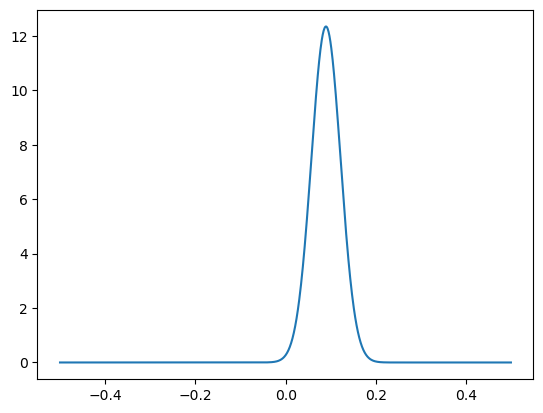

In [129]:
x_axis=np.arange(-0.5, 0.5, 0.001)
mean=0.0892
SD=0.03232
plt.plot(x_axis,norm.pdf(x_axis,mean,SD))

Shows Normal distrubtion for SCC-NT

/var/folders/b2/rp27cvvn1qv01dqtb_ftx4_m0000gn/T/ipykernel_1479/662700182.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nt_pf['Anatomical site'] = nt_pf['Anatomical site'].astype(str)


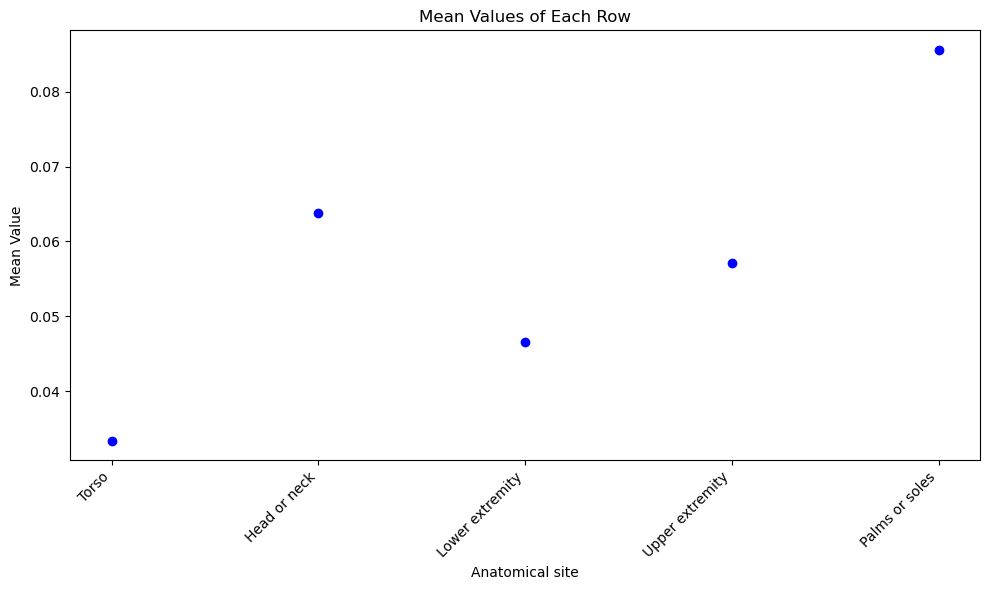

In [113]:
nt_pf['Anatomical site'] = nt_pf['Anatomical site'].astype(str)

# Plot  of the mean values
plt.figure(figsize=(10, 6))
plt.scatter(nt_pf['Anatomical site'], nt_pf['Mean_of_Rows'], color='blue', marker='o')
plt.title('Mean Values of Each Row')
plt.xlabel('Anatomical site')
plt.ylabel('Mean Value')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.tight_layout()
plt.show()

Palms or soles by far the least detectable body part for detecting cancer types

/var/folders/b2/rp27cvvn1qv01dqtb_ftx4_m0000gn/T/ipykernel_1479/109234179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nt_pf['Anatomical site'] = nt_pf['Anatomical site'].astype(str)


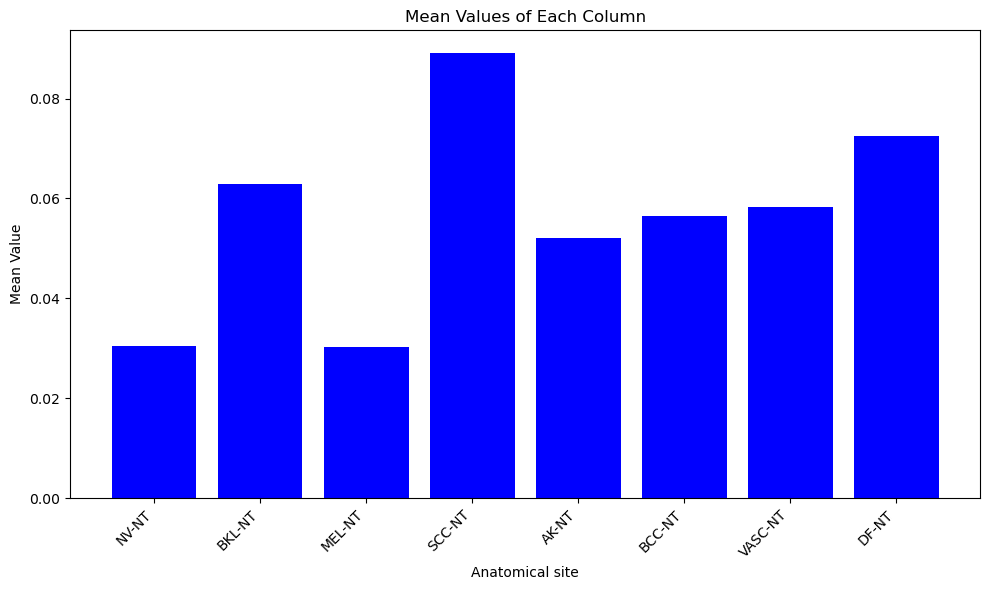

In [114]:
nt_pf['Anatomical site'] = nt_pf['Anatomical site'].astype(str)

plt.figure(figsize=(10, 6))
plt.bar(nt_pf.columns[1:], nt_pf.loc['Mean_of_Columns'][1:], color='blue')
plt.title('Mean Values of Each Column')
plt.xlabel('Anatomical site')
plt.ylabel('Mean Value')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.tight_layout()
plt.show()

Least diagnosable type cancer is SCC-NT

False negative results are rows

Now i am calulating the output of these to see which body part gives us the most 

In [115]:

columns_to_remove = [
    'NV-NV', 'BKL-BKL', 'MEL-MEL', 'SCC-SCC', 'AK-AK', 'BCC-BCC', 'VASC-VASC', 'DF-DF', 'NV-NT', 'BKL-NT', 'MEL-NT', 'SCC-NT', 'AK-NT', 'BCC-NT', 'VASC-NT', 'DF-NT'

]

# new DataFrame without the specified columns
pf2 = pf.drop(columns=columns_to_remove)

(pf2.head(65)
 .style
 .background_gradient(cmap='plasma', axis=None)
 )


,Anatomical site,NV-BKL,NV-MEL,NV-SCC,NV-AK,NV-BCC,NV-VASC,NV-DF,BKL-NV,BKL-MEL,BKL-SCC,BKL-AK,BKL-BCC,BKL-VASC,BKL-DF,MEL-NV,MEL-BKL,MEL-SCC,MEL-AK,MEL-BCC,MEL-VASC,MEL-DF,SCC-NV,SCC-BKL,SCC-MEL,SCC-AK,SCC-BCC,SCC-VASC,SCC-DF,AK-NV,AK-BKL,AK-MEL,AK-SCC,AK-BCC,AK-VASC,AK-DF,BCC-NV,BCC-BKL,BCC-MEL,BCC-SCC,BCC-AK,BCC-VASC,BCC-DF,VASC-NV,VASC-BKL,VASC-MEL,VASC-SCC,VASC-AK,VASC-BCC,VASC-DF,DF-NV,DF-BKL,DF-MEL,DF-SCC,DF-AK,DF-BCC,DF-VASC
0,Torso,0.024000,0.087000,0.002400,0.002700,0.028000,0.001300,0.005300,0.110000,0.180000,0.017000,0.028000,0.090000,0.003300,0.006800,0.210000,0.016000,0.004000,0.007600,0.037000,0.012000,0.003400,0.010000,0.095000,0.012000,0.056000,0.220000,0.007000,0.005200,0.040000,0.240000,0.140000,0.056000,0.280000,0.000000,0.003100,0.021000,0.028000,0.015000,0.009700,0.024000,0.006400,0.003800,0.120000,0.000000,0.002100,0.000000,0.000000,0.029000,0.002100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Head or neck,0.150000,0.120000,0.031000,0.100000,0.160000,0.001000,0.005400,0.022000,0.100000,0.005700,0.230000,0.057000,0.000600,0.001400,0.021000,0.089000,0.003500,0.150000,0.059000,0.000200,0.000000,0.006100,0.094000,0.096000,0.170000,0.220000,0.000000,0.000900,0.011000,0.160000,0.054000,0.005700,0.120000,0.000400,0.002600,0.016000,0.039000,0.022000,0.013000,0.082000,0.001800,0.002400,0.015000,0.000000,0.008400,0.029000,0.004200,0.710000,0.000000,0.000000,0.000000,0.000000,0.000000,0.180000,0.100000,0.000000
2,Lower extremity,0.031000,0.074000,0.000200,0.001400,0.010000,0.002000,0.017000,0.075000,0.080000,0.085000,0.041000,0.110000,0.001700,0.044000,0.170000,0.022000,0.011000,0.004300,0.019000,0.002100,0.016000,0.001700,0.110000,0.037000,0.015000,0.097000,0.000000,0.005000,0.000000,0.160000,0.000000,0.040000,0.200000,0.000000,0.000000,0.012000,0.038000,0.006600,0.057000,0.078000,0.000700,0.042000,0.008000,0.038000,0.046000,0.160000,0.014000,0.084000,0.002000,0.015000,0.018000,0.000000,0.068000,0.006900,0.087000,0.000000
3,Upper extremity,0.027000,0.065000,0.006100,0.008900,0.043000,0.000900,0.012000,0.072000,0.072000,0.057000,0.098000,0.190000,0.003300,0.020000,0.130000,0.057000,0.015000,0.022000,0.051000,0.010000,0.005100,0.030000,0.027000,0.120000,0.020000,0.160000,0.000000,0.017000,0.036000,0.044000,0.046000,0.400000,0.320000,0.002100,0.002100,0.005400,0.033000,0.007800,0.041000,0.026000,0.000000,0.002900,0.007300,0.073000,0.160000,0.011000,0.015000,0.110000,0.029000,0.015000,0.018000,0.000000,0.068000,0.006900,0.087000,0.000000
4,Palms or soles,0.002900,0.190000,0.000000,0.004400,0.041000,0.011000,0.006500,0.080000,0.280000,0.000000,0.000000,0.000000,0.000000,0.000000,0.079000,0.025000,0.017000,0.012000,0.016000,0.018000,0.000300,0.000000,0.090000,0.000000,0.010000,0.000000,0.000000,0.210000,nan,nan,nan,nan,nan,nan,nan,0.000000,0.004400,0.040000,0.022000,0.200000,0.000000,0.004400,0.016000,0.000000,0.780000,0.000000,0.000000,0.000000,0.000000,0.091000,0.019000,0.050000,0.018000,0.070000,0.200000,0.008000


Here we can see the output of false positive results using CNN.
With the color map we have used we can see outliers which are lighter(more yellow) in colour
We can see the algorithmns could not distinguish vascular leisons but instead assigining it to basal cell carcinoma when on the neck area however with previous data displayed below we can see there is not as many dermoscopic pictures in that area so this could be down to pure chance of not very clear images for the program. This assumption can also be substanciated by the fact that the remaining cells below and above are much lower in value. The same theory goes for vascular leisons being misdiagnosed for melonma on palms/soles.

Clearly low amount dermoscopic pictures with vascular leisons so not fair to assume there is a correlation between vascular leisons and its false postive results for other types of cancer.

Creating an aggrete score for each false postive result will show us what the CNN struggles distingusiing the most
Creating aggregate score for each body part will show us what the CNN struggles with

In [116]:
pf2['Mean_of_Rows'] = pf2.iloc[:, 1:].mean(axis=1)
pf2.loc['Mean_of_Columns'] = pf2.select_dtypes(include='number').mean()
(pf2.head(65)
 .style
 .background_gradient(cmap='plasma', axis=None)
 )


,Anatomical site,NV-BKL,NV-MEL,NV-SCC,NV-AK,NV-BCC,NV-VASC,NV-DF,BKL-NV,BKL-MEL,BKL-SCC,BKL-AK,BKL-BCC,BKL-VASC,BKL-DF,MEL-NV,MEL-BKL,MEL-SCC,MEL-AK,MEL-BCC,MEL-VASC,MEL-DF,SCC-NV,SCC-BKL,SCC-MEL,SCC-AK,SCC-BCC,SCC-VASC,SCC-DF,AK-NV,AK-BKL,AK-MEL,AK-SCC,AK-BCC,AK-VASC,AK-DF,BCC-NV,BCC-BKL,BCC-MEL,BCC-SCC,BCC-AK,BCC-VASC,BCC-DF,VASC-NV,VASC-BKL,VASC-MEL,VASC-SCC,VASC-AK,VASC-BCC,VASC-DF,DF-NV,DF-BKL,DF-MEL,DF-SCC,DF-AK,DF-BCC,DF-VASC,Mean_of_Rows
0,Torso,0.024000,0.087000,0.002400,0.002700,0.028000,0.001300,0.005300,0.110000,0.180000,0.017000,0.028000,0.090000,0.003300,0.006800,0.210000,0.016000,0.004000,0.007600,0.037000,0.012000,0.003400,0.010000,0.095000,0.012000,0.056000,0.220000,0.007000,0.005200,0.040000,0.240000,0.140000,0.056000,0.280000,0.000000,0.003100,0.021000,0.028000,0.015000,0.009700,0.024000,0.006400,0.003800,0.120000,0.000000,0.002100,0.000000,0.000000,0.029000,0.002100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.041093
1,Head or neck,0.150000,0.120000,0.031000,0.100000,0.160000,0.001000,0.005400,0.022000,0.100000,0.005700,0.230000,0.057000,0.000600,0.001400,0.021000,0.089000,0.003500,0.150000,0.059000,0.000200,0.000000,0.006100,0.094000,0.096000,0.170000,0.220000,0.000000,0.000900,0.011000,0.160000,0.054000,0.005700,0.120000,0.000400,0.002600,0.016000,0.039000,0.022000,0.013000,0.082000,0.001800,0.002400,0.015000,0.000000,0.008400,0.029000,0.004200,0.710000,0.000000,0.000000,0.000000,0.000000,0.000000,0.180000,0.100000,0.000000,0.061970
2,Lower extremity,0.031000,0.074000,0.000200,0.001400,0.010000,0.002000,0.017000,0.075000,0.080000,0.085000,0.041000,0.110000,0.001700,0.044000,0.170000,0.022000,0.011000,0.004300,0.019000,0.002100,0.016000,0.001700,0.110000,0.037000,0.015000,0.097000,0.000000,0.005000,0.000000,0.160000,0.000000,0.040000,0.200000,0.000000,0.000000,0.012000,0.038000,0.006600,0.057000,0.078000,0.000700,0.042000,0.008000,0.038000,0.046000,0.160000,0.014000,0.084000,0.002000,0.015000,0.018000,0.000000,0.068000,0.006900,0.087000,0.000000,0.040421
3,Upper extremity,0.027000,0.065000,0.006100,0.008900,0.043000,0.000900,0.012000,0.072000,0.072000,0.057000,0.098000,0.190000,0.003300,0.020000,0.130000,0.057000,0.015000,0.022000,0.051000,0.010000,0.005100,0.030000,0.027000,0.120000,0.020000,0.160000,0.000000,0.017000,0.036000,0.044000,0.046000,0.400000,0.320000,0.002100,0.002100,0.005400,0.033000,0.007800,0.041000,0.026000,0.000000,0.002900,0.007300,0.073000,0.160000,0.011000,0.015000,0.110000,0.029000,0.015000,0.018000,0.000000,0.068000,0.006900,0.087000,0.000000,0.051889
4,Palms or soles,0.002900,0.190000,0.000000,0.004400,0.041000,0.011000,0.006500,0.080000,0.280000,0.000000,0.000000,0.000000,0.000000,0.000000,0.079000,0.025000,0.017000,0.012000,0.016000,0.018000,0.000300,0.000000,0.090000,0.000000,0.010000,0.000000,0.000000,0.210000,nan,nan,nan,nan,nan,nan,nan,0.000000,0.004400,0.040000,0.022000,0.200000,0.000000,0.004400,0.016000,0.000000,0.780000,0.000000,0.000000,0.000000,0.000000,0.091000,0.019000,0.050000,0.018000,0.070000,0.200000,0.008000,0.053386
Mean_of_Columns,nan,0.046980,0.107200,0.007940,0.023480,0.056400,0.003240,0.009240,0.071800,0.142400,0.032940,0.079400,0.089400,0.001780,0.014440,0.122000,0.041800,0.010100,0.039180,0.036400,0.008460,0.004960,0.009560,0.083200,0.053000,0.054200,0.139400,0.001400,0.047620,0.021750,0.151000,0.060000,0.125425,0.230000,0.000625,0.001950,0.010880,0.028480,0.018280,0.028540,0.082000,0.001780,0.011100,0.033260,0.022200,0.199300,0.040000,0.006640,0.186600,0.006620,0.024200,0.011000,0.010000,0.030800,0.052760,0.094800,0.001600,0.049752


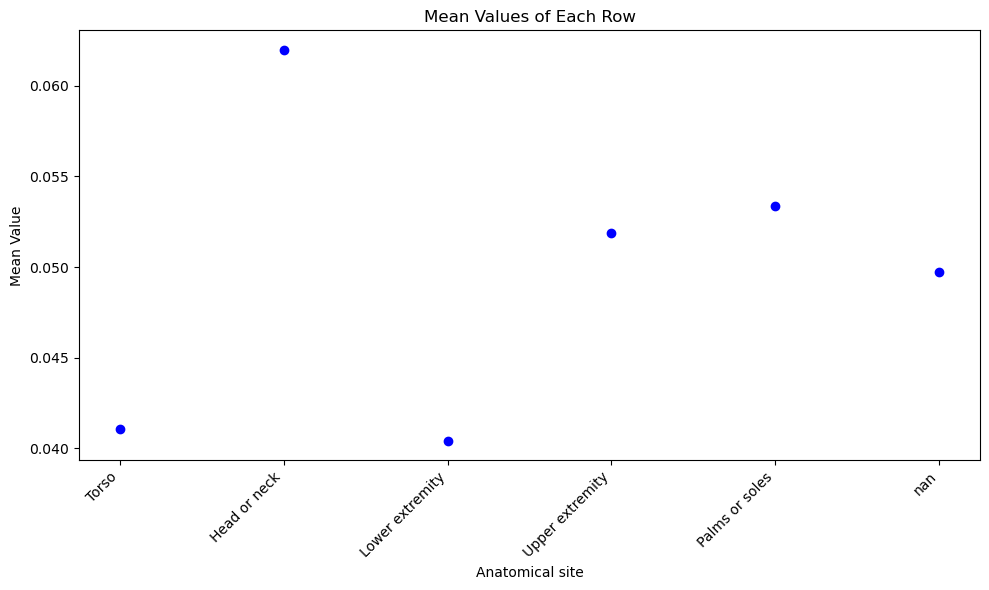

In [117]:
pf2['Anatomical site'] = pf2['Anatomical site'].astype(str)

# Plot the mean values
plt.figure(figsize=(10, 6))
plt.scatter(pf2['Anatomical site'], pf2['Mean_of_Rows'], color='blue', marker='o')
plt.title('Mean Values of Each Row')
plt.xlabel('Anatomical site')
plt.ylabel('Mean Value')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.tight_layout()
plt.show()

Shows a big discrepency where using CNN on the dermoscopic images on the head/neck area gives most false positive results, however only 168+128/10015 so less abundant compared to others - cant reach conclusion of if CNN is failing on these images.

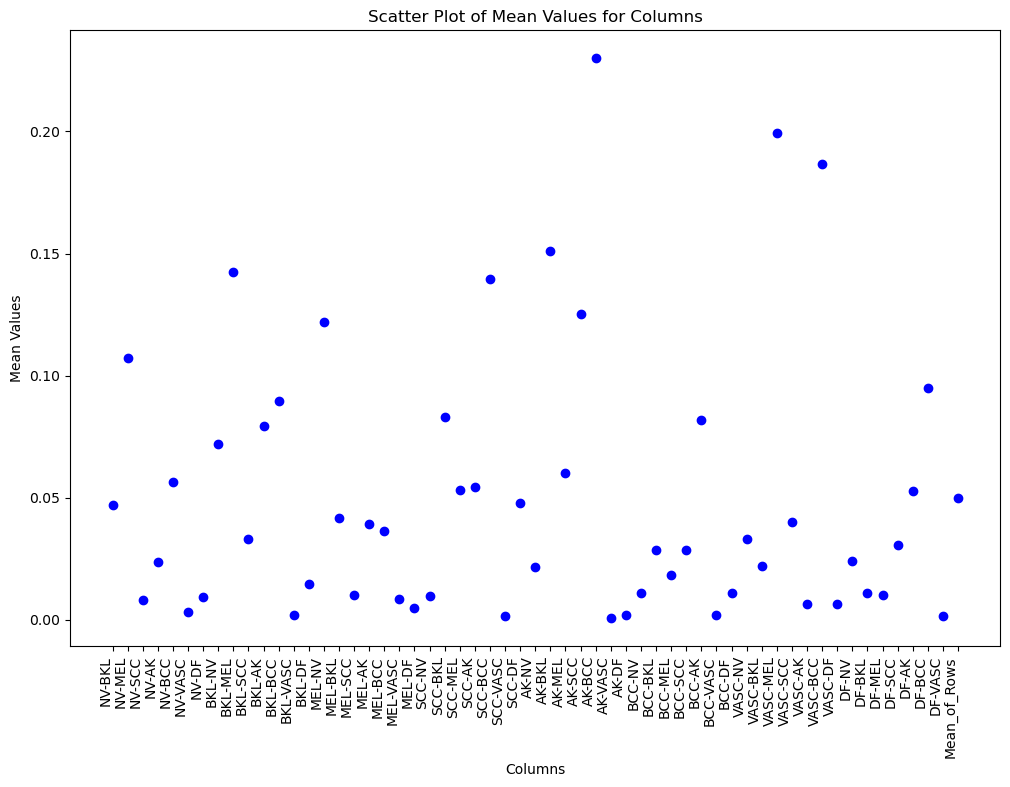

In [118]:
mean_of_columns = pf2.select_dtypes(include='number').mean()
plt.figure(figsize=(12,8))
plt.scatter(mean_of_columns.index, mean_of_columns.values, color='blue', marker='o')
plt.title('Scatter Plot of Mean Values for Columns')
plt.xlabel('Columns')
plt.ylabel('Mean Values')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability
plt.show()

The false postive result of Actinic keratoses being mistaking for basal cell carcinoma is very high could be indicating the overall shape Tumor Morphology, Texture and Density, Microcalcifications, Vascular Patterns, Tissue Composition, Edge and Boundary Features, Spatial Arrangement, Color Variations, Architectural Distortions.

In [ ]:
x_axis=np.arange(0,175,1)
mean=90.277778
SD=8.476997
plt.plot(x_axis,norm.pdf(x_axis,mean,SD))

# <u>Conclusion</u>
In conclusion we can see that Nevi is the best type of cancer to test the effectiveness of CNN as it has majority of the dermascopic images. The samll pool of other types make all other uses of the algorithms on thsoes types of cacner inconlusive.


However with NEVI we can see that the CNN is very effective with results having an 84 percent chance of being correctly assigned to nevi.